In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import glob, natsort, os

from src.file_path import list_files_in_folder, filter_cvm_files, find_seq_file
from src.metadata_utils import extract_CVM_dataframe, extract_read_CVM_dataframes, sort_memcvm_dfs, build_wide_dataframe_from_list, seq_file_parsing, write_csv_with_metadata
from src.plot import plot_memCVM_overview, plot_memCVM_Vwrite, plot_memCVM_vs_pulse_number, Dashboard_memCVM

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# This code is used to plot the data from the FE tester for the CV
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget


In [2]:

folder_path = r"E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\mem-CVM\Proto_09"
output_path = r"E:\Polybox\06 - FeCAP-FTJ\01 - Results\02 - FE tester\NASA_FeCAP_05\mem-CVM\Proto_09"
READING_VOLTAGE = 0.35      # In V, The value must be £inside the window of the Bias reading voltage otherwise you'll get an error !

print("Reading data from folder: ", folder_path)

Reading data from folder:  E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\mem-CVM\Proto_09


In [3]:
CVM_reading_files, CVM_complete_file = filter_cvm_files(list_files_in_folder(folder_path))
Read_CVM_Dataframe: list = []
Vwrite_list: list = []

Main_CVM_Dataframe = extract_CVM_dataframe(CVM_complete_file)
Read_CVM_Dataframe = extract_read_CVM_dataframes(CVM_reading_files)

Read_CVM_Dataframe, Vwrite_list = sort_memcvm_dfs(Read_CVM_Dataframe)

Dashboard saved to: E:\Polybox\06 - FeCAP-FTJ\01 - Results\02 - FE tester\NASA_FeCAP_05\mem-CVM\Proto_09\2026-01-07_NASA-FeCAP-05_Dashboard.png


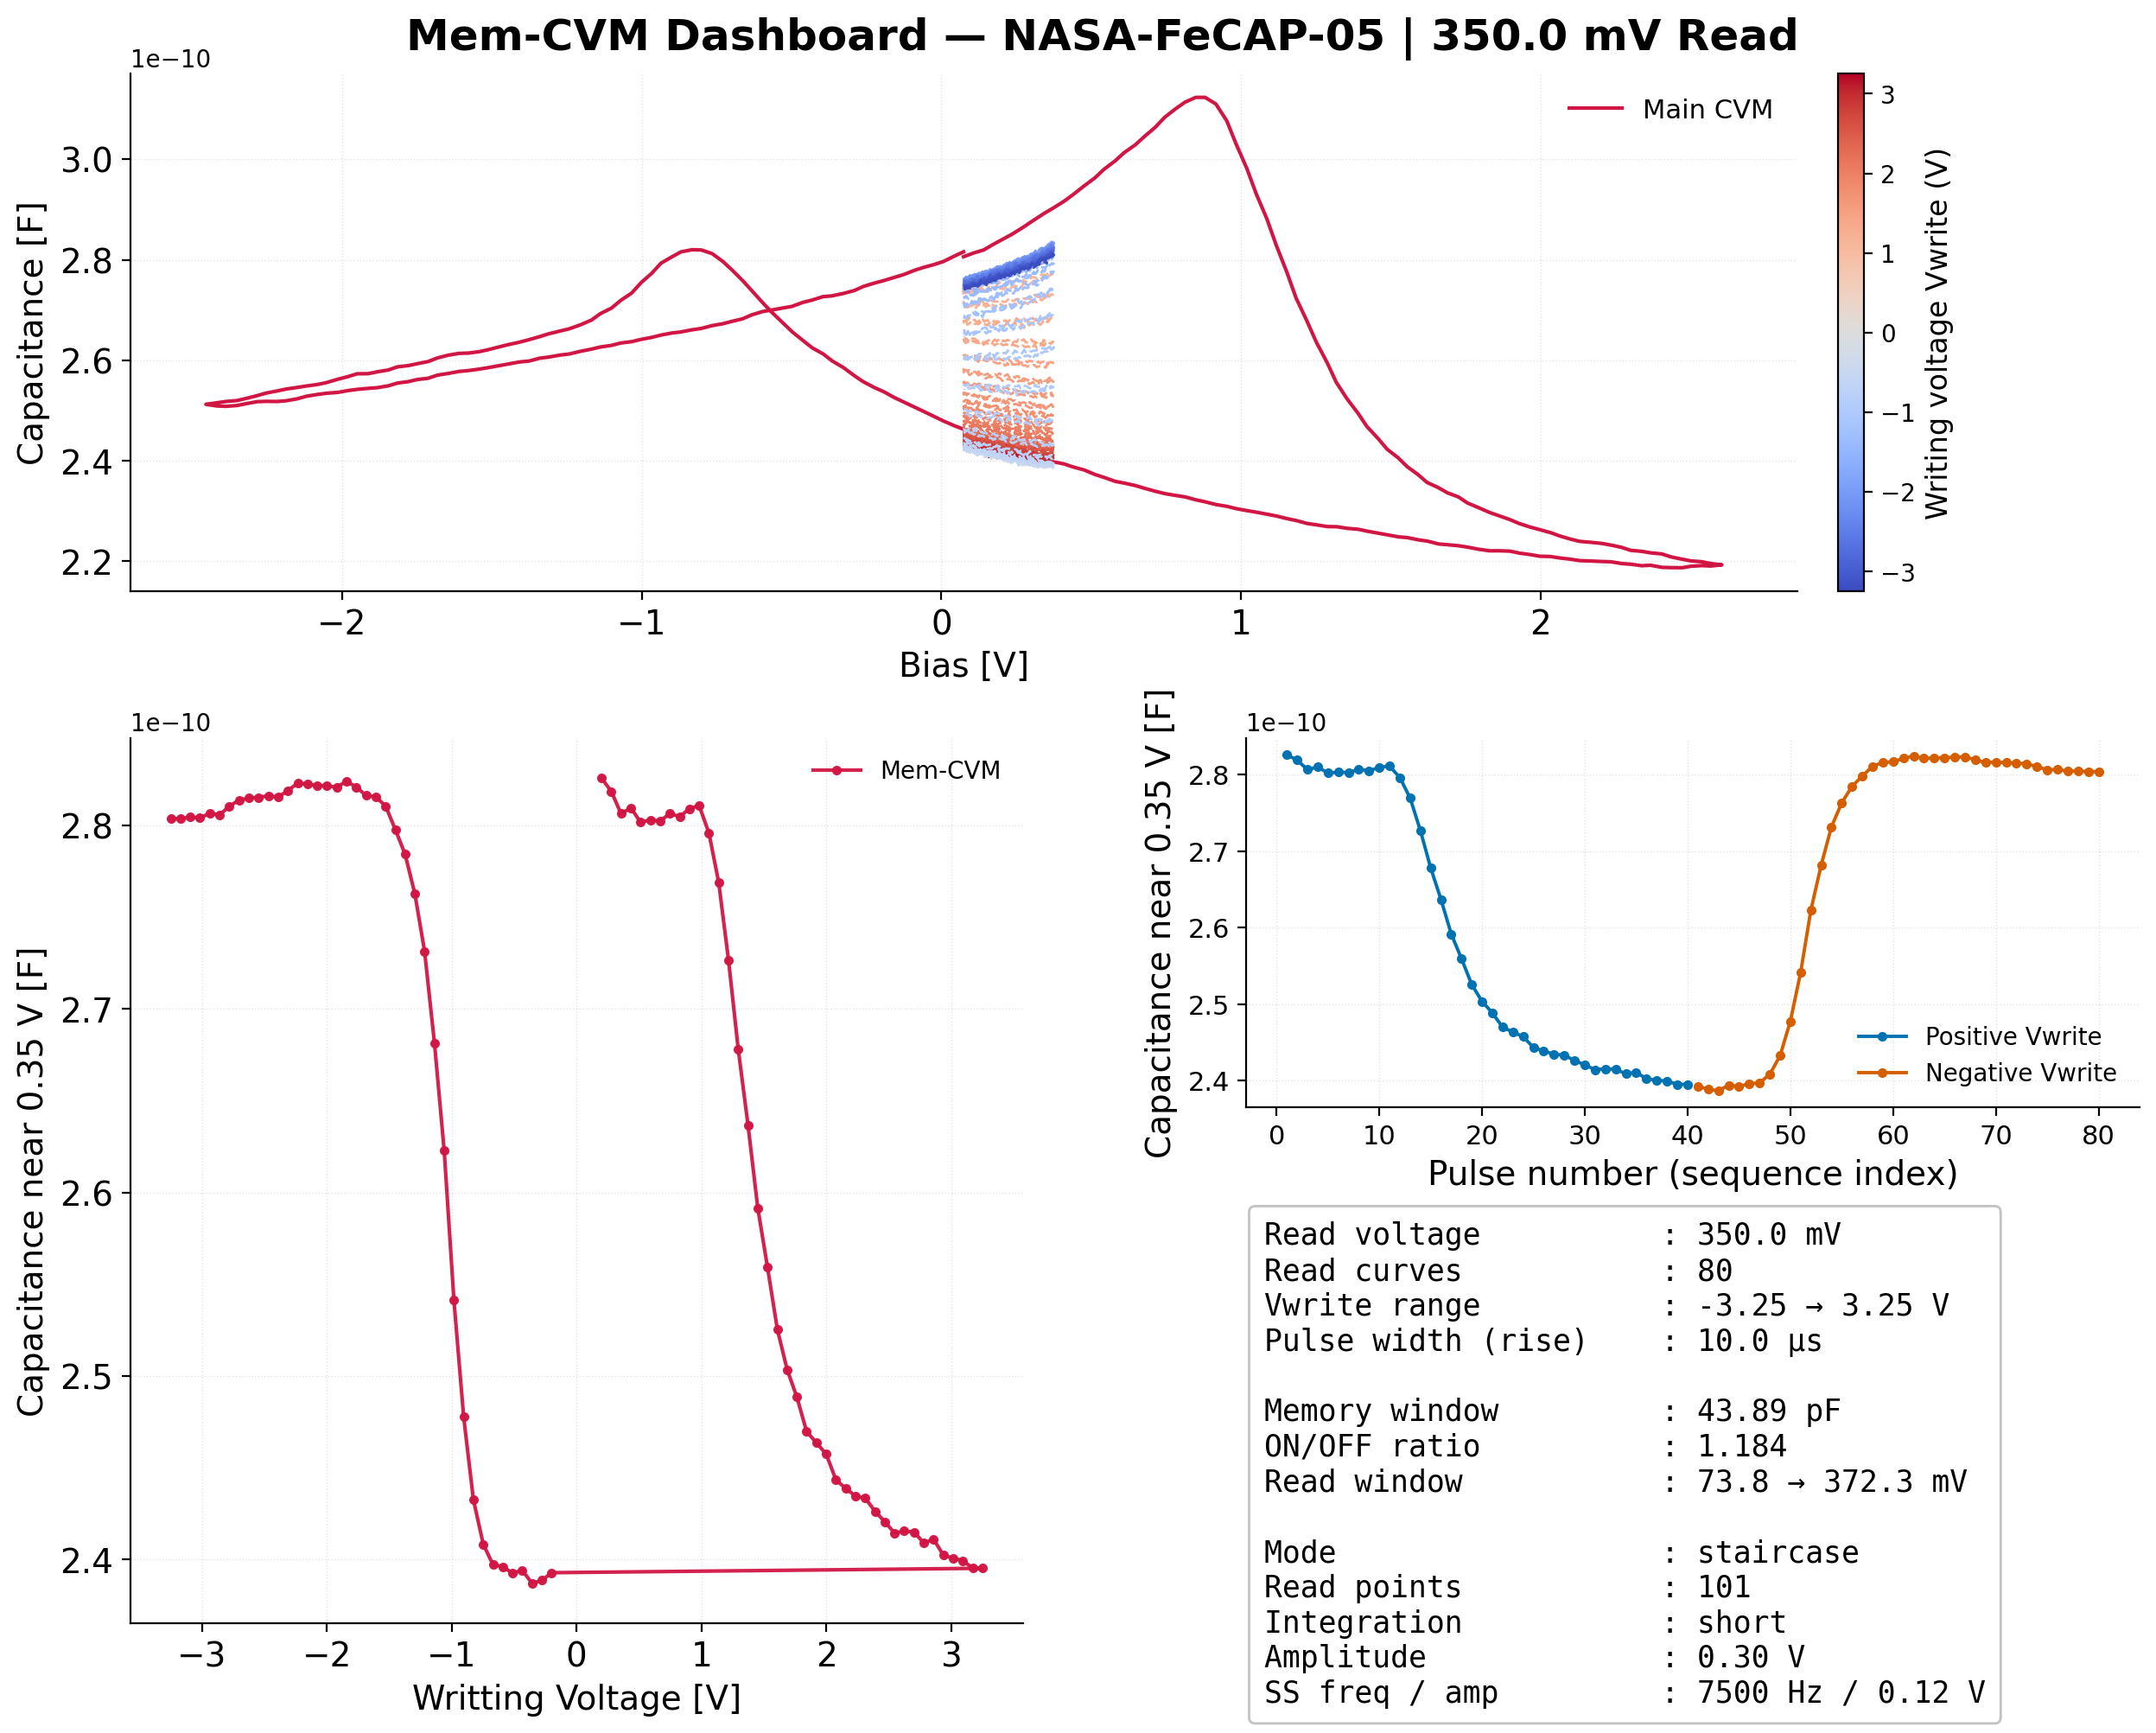

In [4]:
Dashboard_memCVM(Main_CVM_Dataframe=Main_CVM_Dataframe, Read_CVM_Dataframe=Read_CVM_Dataframe, Vwrite_list=Vwrite_list, reading_voltage=READING_VOLTAGE, path_metadata=folder_path, Output_path=output_path)

In [5]:
Metadata_df = seq_file_parsing(folder_path)
READ_dataframe_CSV = build_wide_dataframe_from_list(Read_CVM_Dataframe,Vwrite_list= Vwrite_list, v_col="Bias [V]", c_col= "C [F]")
write_csv_with_metadata(Output_path=output_path, df_metadata=Metadata_df, df_data=READ_dataframe_CSV)

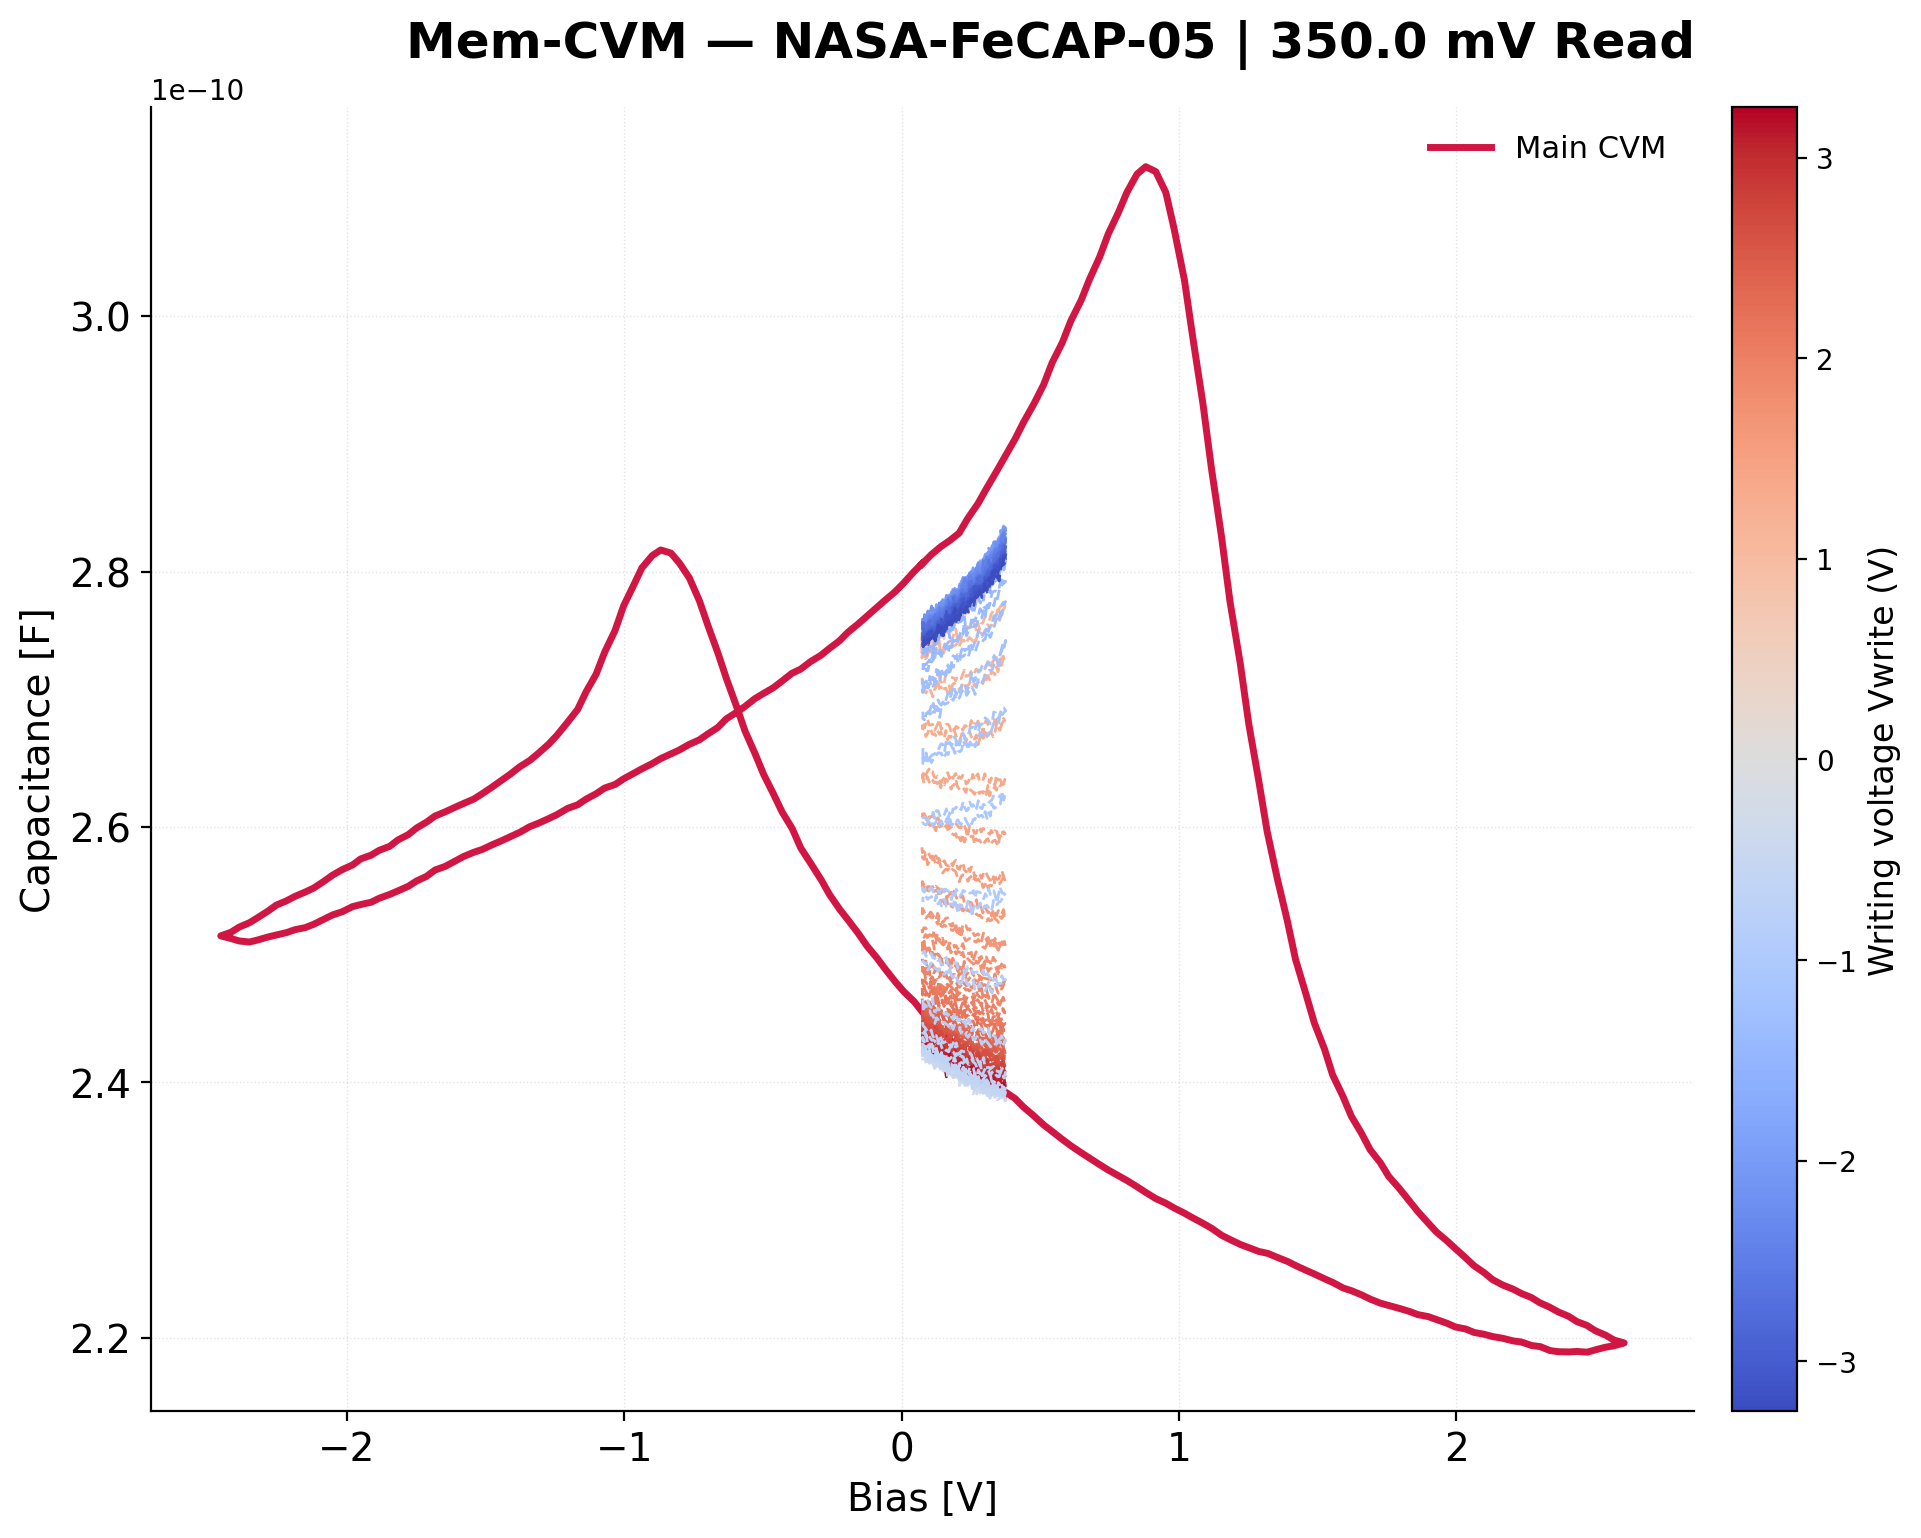

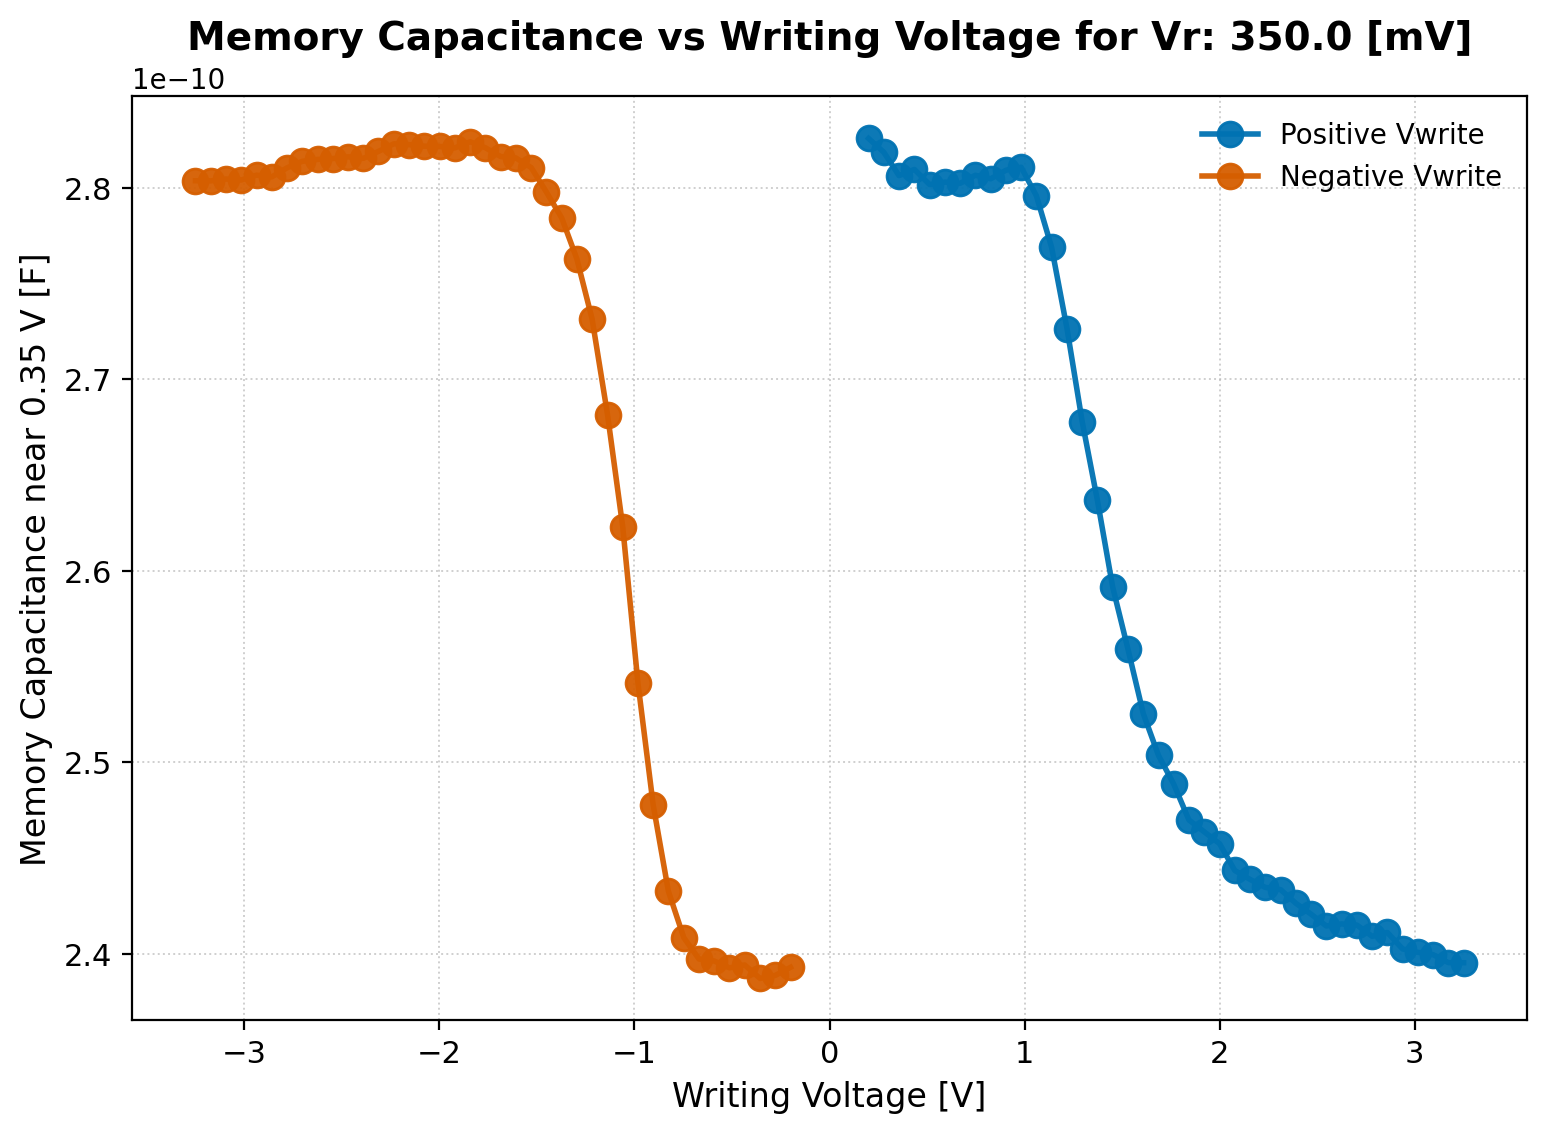

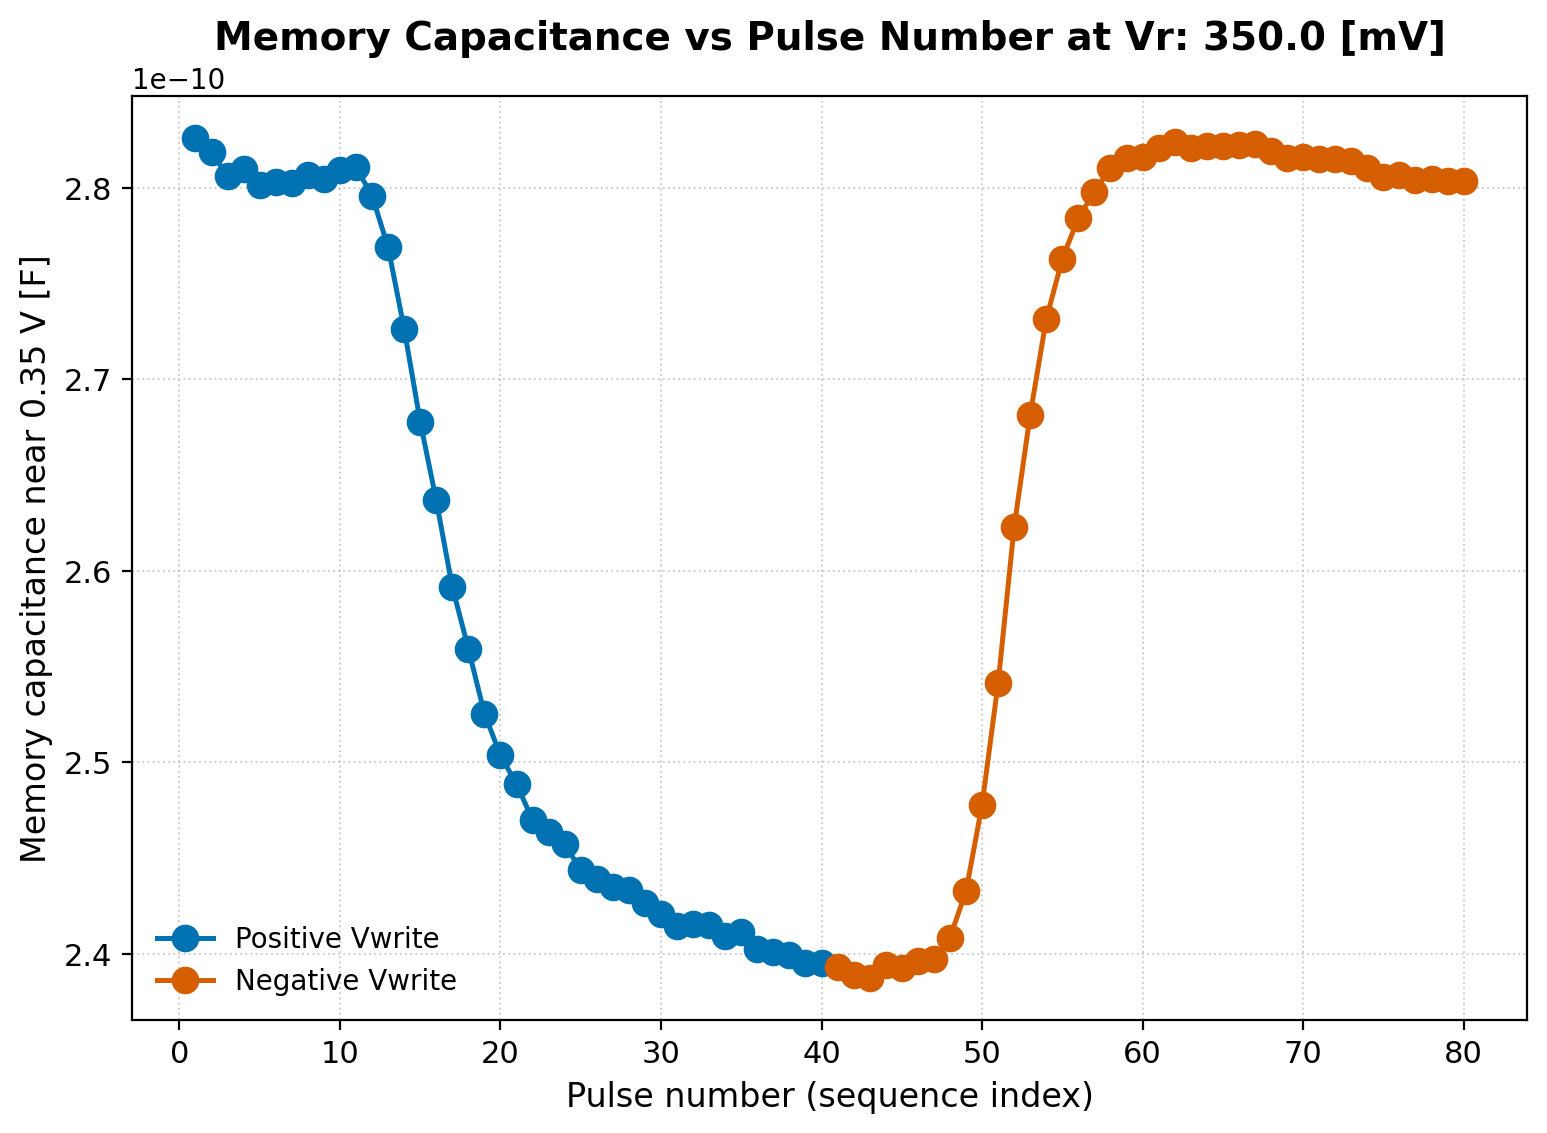

In [6]:
plot_memCVM_overview(Main_CVM_Dataframe=Main_CVM_Dataframe, Read_CVM_Dataframe=Read_CVM_Dataframe, path_metadata=folder_path, Output_path=output_path, reading_voltage=READING_VOLTAGE, Vwrite_list=Vwrite_list)
plot_memCVM_Vwrite(Read_CVM_Dataframe=Read_CVM_Dataframe, path_metadata=folder_path, Output_path=output_path, reading_voltage=READING_VOLTAGE)
plot_memCVM_vs_pulse_number(Read_CVM_Dataframe=Read_CVM_Dataframe, path_metadata=folder_path, Output_path=output_path, Vwrite_list=Vwrite_list, reading_voltage=READING_VOLTAGE)